In [ ]:
#Lab01
import gymnasium as gym

In [ ]:
#1. Modify the code to print observation and reward at each step.
env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset()

for _ in range(500):
  action = env.action_space.sample()
  obs, reward, done, truncated, info = env.step(action)

  print("observation", obs)
  print("reward", reward)
  if done or truncated:
    obs, info = env.reset()
env.close()


In [ ]:
#2.    Try a different environment:
env = gym.make("MountainCar-v0", render_mode="human")
obs, info = env.reset()

for _ in range(500):
  action = env.action_space.sample()
  obs, reward, done, truncated, info = env.step(action)

  if done or truncated:
    obs, info = env.reset()
env.close()

In [ ]:
# 3. env = gym.make("MountainCar-v0", render_mode="human").
#Compare its difficulty with CartPole.

env1 = gym.make("CartPole-v1", render_mode="human")
env2 = gym.make("MountainCar-v0", render_mode="human")

obs1, info = env1.reset()
obs2, info = env2.reset()

for i in range(500):
  action1 = env1.action_space.sample()
  action2 = env2.action_space.sample()

  obs1, reward1, done1, truncated1, info = env1.step(action1)
  obs2, reward2, done2, truncated2, info = env2.step(action2)

  if done1 or truncated1:
    print("CartPole at Step: ", i)
    print("observation", obs1)
    print("reward", reward1)
    obs1, info = env1.reset()
  if done2 or truncated2:
    print("MountainCar at Step: ", i)
    print("observation", obs2)
    print("reward", reward2)
    obs2, info = env2.reset()

env1.close()
env2.close()

# Đánh giá: CartPole: hoàn thành trò chơi dễ dàng hơn MountainCar
# Khi chạy thử tôi thấy: CartPole kết thúc 1 trò chơi chỉ từ vài step đến vài chục step
# Trong khi đó để MountainCar kết thúc cần ít nhất 100<step<=200step
# Reward: CartPole: +1; MountainCar: -1

In [ ]:
#4.    Explore environment properties:
env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset()

for _ in range(3):
  action = env.action_space.sample()
  obs, reward, done, truncated, info = env.step(action)

  print("action_space", env.action_space.n) # (2): có 2 action[0,1] lần lượt là đẩy trái, đẩy phải
  print("observation_space", env.observation_space)

  if done or truncated:
    obs, info = env.reset()
env.close()


In [ ]:
# •    Exercise A – Action Repetition:
#Write a loop where the same action (e.g., always 0) is repeated. Observe how the agent performs compared to random actions.

env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset()

for _ in range(500):
  total_step = 0
  total_reward = 0
  action = 0
  obs, reward, done, truncated, info = env.step(action)
  total_step += 1
  total_reward += reward

  if done or truncated:
    obs, info = env.reset()

env.close()
print("Total_step", total_step)
print("Total_reward", total_reward)

Total_step 1
Total_reward 1.0


In [ ]:
#Exercise B – Deterministic vs. Stochastic:
#Run the environment multiple times with the same sequence of actions. Check if the results are identical or slightly different.
import numpy as np
actions = [1, 0, 1, 1, 0, 1]

def run_enviroment():
  env = gym.make("CartPole-v1")
  obs, info = env.reset()
  check = []
  for a in actions:
    action = a
    obs, reward, done, truncated, info = env.step(action)
    check.append(obs)
    if done or truncated:
      break
  env.close()
  return check

env1 = run_enviroment()
env2 = run_enviroment()


env1 = np.array(env1)
env2 = np.array(env2)

print(env1==env2)
# Khi thay đổi môi env thì kết quả vẫn là khác mọi obs
# Lí do: khả năng là obs thay đổi


[[False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]]


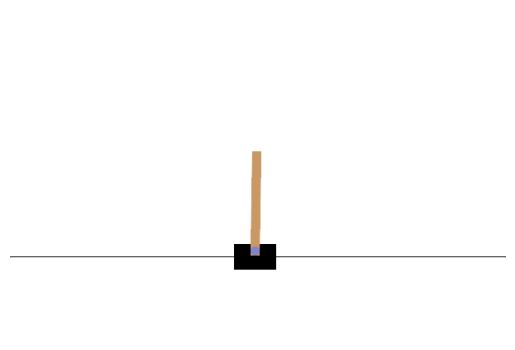

In [ ]:
#•    Exercise C – Custom Rendering:
#Instead of using render_mode="human", use render_mode="rgb_array" and display frames with matplotlib. Save an animation of the agent’s behavior.

import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.animation as animation

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset()

frames = []
for _ in range(200):
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    frames.append(env.render())   # mỗi lần render trả về 1 ảnh (numpy array)
    if done or truncated:
        obs, info = env.reset()

env.close()

# Lưu thành animation GIF/MP4
fig = plt.figure()
plt.axis("off")
im = plt.imshow(frames[0])

def update(i):
    im.set_array(frames[i])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=50)
ani.save("cartpole_run.gif", writer="pillow")

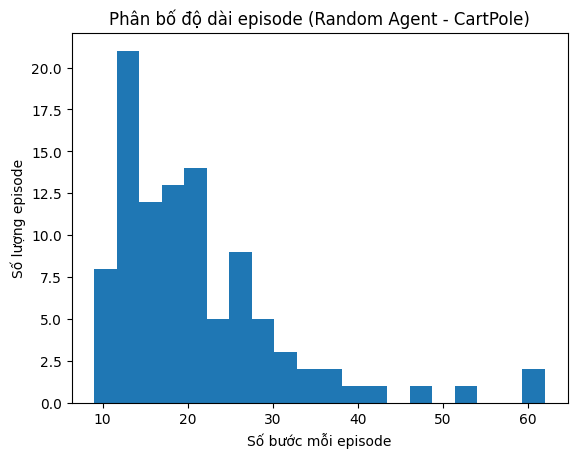

In [ ]:
#•    Exercise D – Episode Statistics:
#Count how many steps each episode lasts when using random actions. Plot a histogram of episode lengths.
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")
episode_lengths = []

for episode in range(100):
    obs, info = env.reset()
    steps = 0
    done = truncated = False
    while not (done or truncated):
        action = env.action_space.sample()
        obs, reward, done, truncated, info = env.step(action)
        steps += 1
    episode_lengths.append(steps)

env.close()

plt.hist(episode_lengths, bins=20)
plt.xlabel("Số bước mỗi episode")
plt.ylabel("Số lượng episode")
plt.title("Phân bố độ dài episode (Random Agent - CartPole)")
plt.show()

In [ ]:
#•    Exercise E – Reward Analysis:
#Track the cumulative reward per episode. Plot average rewards over 20 episodes for CartPole and MountainCar.

import gymnasium as gym
import matplotlib.pyplot as plt

def run_experiment(env_name, n_episodes=20):
    env = gym.make(env_name)
    episode_rewards = []

    for episode in range(n_episodes):
        obs, info = env.reset()
        total_reward = 0
        done = truncated = False
        while not (done or truncated):
            action = env.action_space.sample()
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
        episode_rewards.append(total_reward)

    env.close()
    return episode_rewards

cartpole_rewards = run_experiment("CartPole-v1")
mountaincar_rewards = run_experiment("MountainCar-v0")

print("CartPole Rewards:", cartpole_rewards)
print("MountainCar Rewards:", mountaincar_rewards)

CartPole Rewards: [19.0, 24.0, 10.0, 45.0, 21.0, 15.0, 22.0, 13.0, 36.0, 19.0, 12.0, 41.0, 19.0, 20.0, 13.0, 27.0, 16.0, 42.0, 10.0, 31.0]
MountainCar Rewards: [-200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0]


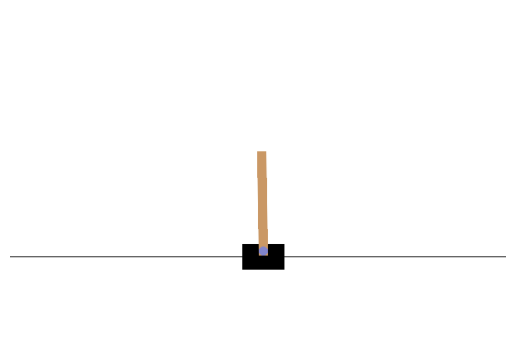

In [ ]:
env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset()
for _ in range(200):
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        obs, info = env.reset()
env.close()

import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset()

img = env.render()
plt.imshow(img)
plt.axis("off")
plt.show()

env.close()
#Human mode mở cửa sổ để xem trực tiếp nhưng không lưu lại được dữ liệu gì; rgb_array mode trả về ảnh dạng numpy array, không hiện cửa sổ nhưng lưu/xử lý/ghép video được.

#→ rgb_array hữu ích hơn để ghi lại kết quả, vì nó tạo ra dữ liệu có thể lưu file và đính kèm báo cáo, còn human mode chỉ để xem trực tiếp bằng mắt lúc chạy.

In [ ]:
# Setup
import pygame
env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset()

print("Use LEFT arrow and RIGHT arrow to control the cart. Press ESC to quit.")

running = True
done = False       # Khởi tạo trước để tránh lỗi NameError khi chưa nhấn phím nào
truncated = False

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False
            elif event.key == pygame.K_LEFT:
                action = 0   # move left
                obs, reward, done, truncated, info = env.step(action)
            elif event.key == pygame.K_RIGHT:
                action = 1   # move right
                obs, reward, done, truncated, info = env.step(action)

    if done or truncated:
        obs, info = env.reset()
        done, truncated = False, False

env.close()

**Nhận xét Exercise G (Keyboard Control):**

- CartPole: Khi điều khiển thủ công bằng tay, người chơi có thể quan sát và phản ứng theo
  độ nghiêng của cây gậy nên thường giữ thăng bằng được lâu hơn agent hành động ngẫu nhiên
  (có thể đạt hàng trăm bước nếu phản xạ tốt).
- MountainCar: khó điều khiển thủ công hơn vì cần tích lũy đà (momentum) bằng cách đẩy qua lại
  nhiều lần trước khi đủ lực leo lên cờ — người mới chơi thường mất nhiều lần thử mới đến được đích.

In [ ]:
# Exercise H – Interactive Sliders (Optional, Jupyter Notebook only)
# Students can use ipywidgets sliders to control actions in real-time.
import gymnasium as gym
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

env = gym.make("MountainCar-v0", render_mode="rgb_array")
obs, info = env.reset()

def step(action):
    global obs
    obs, reward, done, truncated, info = env.step(int(action))
    frame = env.render()
    plt.figure(figsize=(4, 3))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()
    print("observation:", obs, "| reward:", reward)
    if done or truncated:
        obs, info = env.reset()

widgets.interact(step, action=widgets.IntSlider(min=0, max=2, step=1, value=0))

**Nhận xét Exercise H (Interactive Sliders):**

- Action 0 = đẩy xe sang trái, action 1 = không tác động (đứng yên), action 2 = đẩy xe sang phải.
- Việc kéo slider qua lại giữa 0 và 2 giúp quan sát trực quan cách agent cần tích lũy đà
  (momentum) bằng cách đẩy qua lại nhiều lần thay vì chỉ đẩy một chiều mới có thể vượt được đỉnh dốc để đến cờ.